Loaded 'amazon_df' from 'amazon_paint_data.csv'.


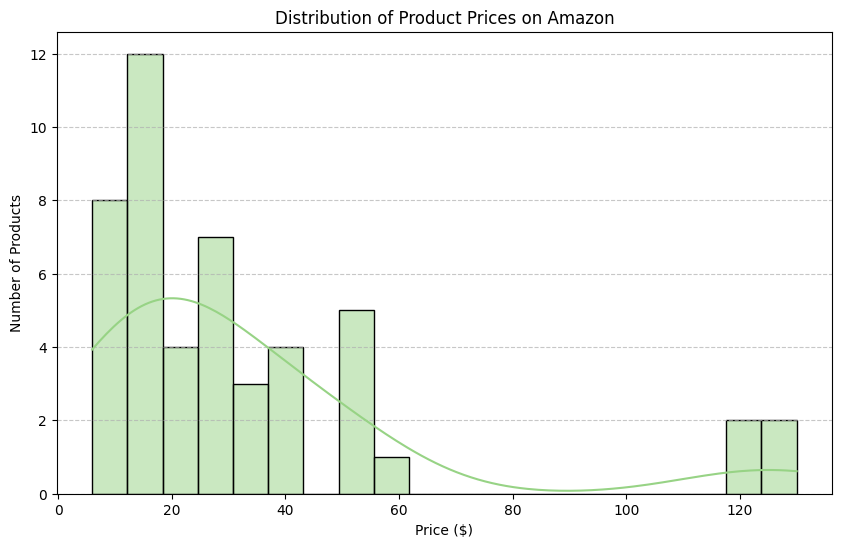

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os


amazon_df = pd.read_csv('amazon_paint_data.csv')
print("Loaded 'amazon_df' from 'amazon_paint_data.csv'.")

# --- 1. Price Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(amazon_df['price_num'].dropna(), bins=20, kde=True, color=sns.color_palette('YlGn')[2])
plt.title('Distribution of Product Prices on Amazon')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

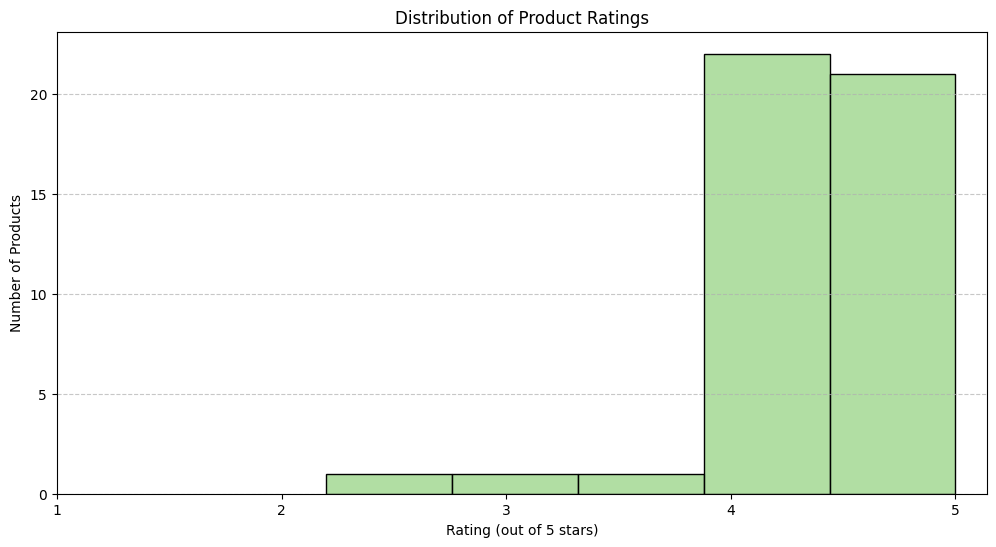

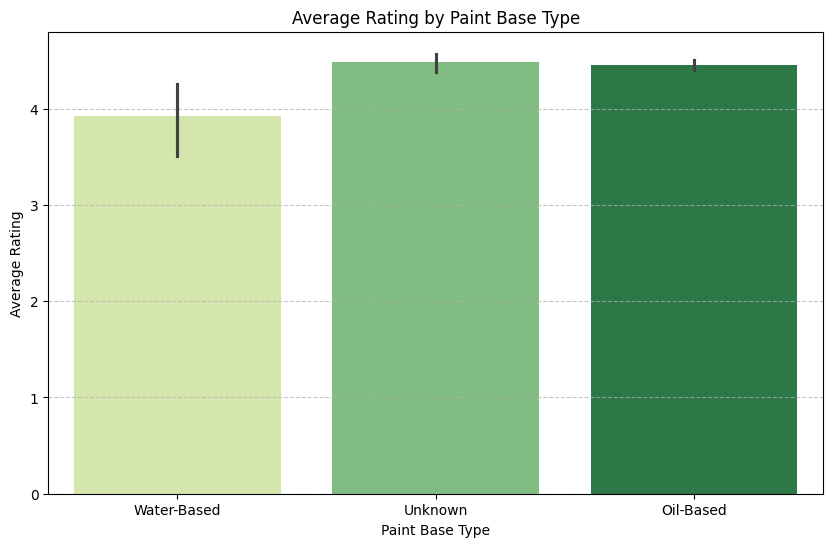

In [15]:

# --- 2. Rating Analysis: Distribution and Average Rating by Base Type ---

plt.figure(figsize=(12, 6))
sns.histplot(amazon_df['rating_num'].dropna(), bins=5, kde=False, stat='count', color=sns.color_palette('YlGn')[2])
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (out of 5 stars)')
plt.ylabel('Number of Products')
plt.xticks(range(1, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='base_type', y='rating_num', data=amazon_df.dropna(subset=['base_type', 'rating_num']), estimator=lambda x: sum(x)/len(x), palette=sns.color_palette('YlGn', 3), hue='base_type', legend=False)
plt.title('Average Rating by Paint Base Type')
plt.xlabel('Paint Base Type')
plt.ylabel('Average Rating')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

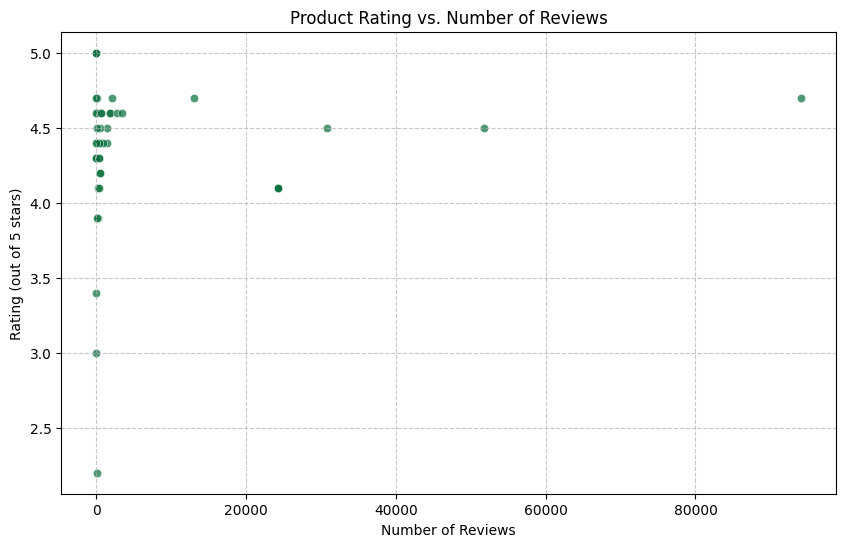

In [18]:

# --- 3. Review Count vs. Rating (Scatter Plot) ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x='reviews_num', y='rating_num', data=amazon_df.dropna(subset=['reviews_num', 'rating_num']), alpha=0.7, color=sns.color_palette('YlGn')[5])
plt.title('Product Rating vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating (out of 5 stars)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

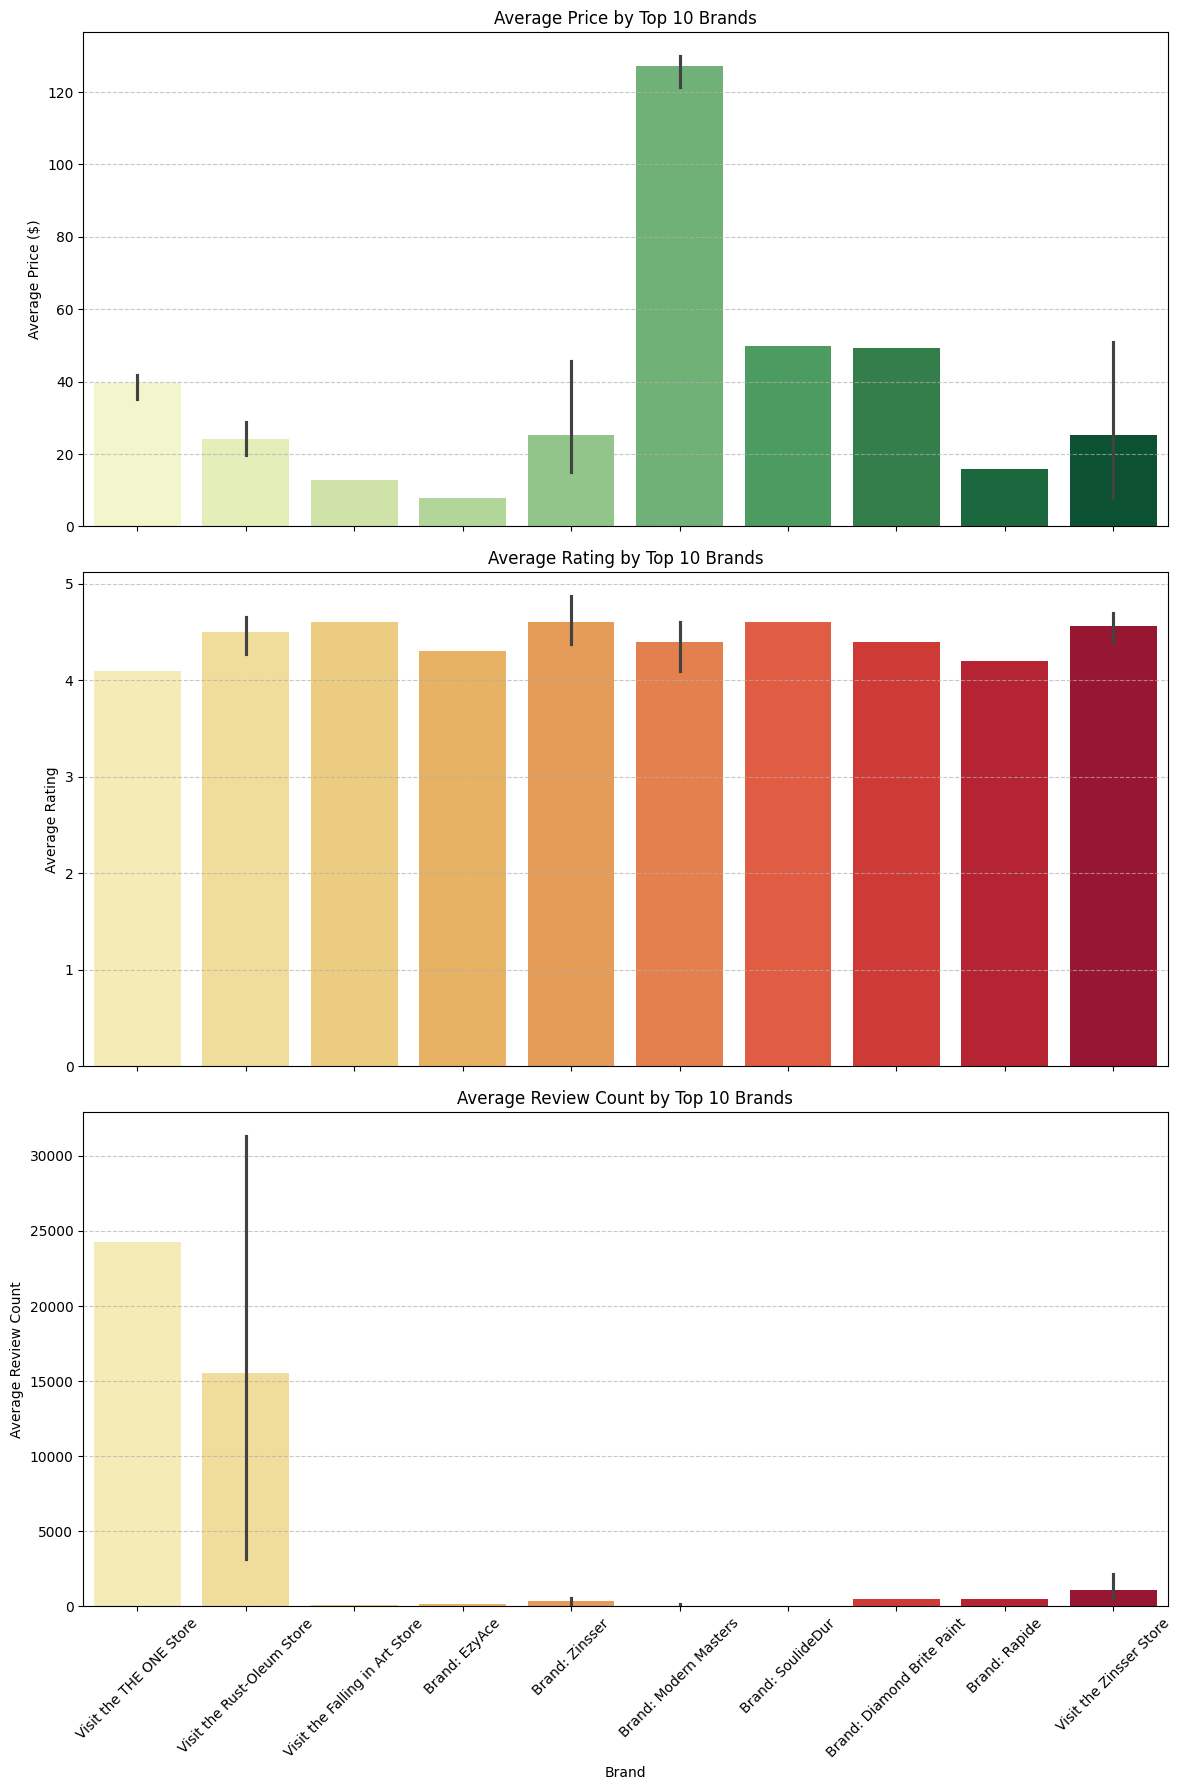

In [13]:

# --- 4. Brand Performance: Average Price, Rating, and Review Counts ---

# Get top N brands by number of products for clarity
top_brands = amazon_df['brand'].value_counts().nlargest(10).index
brand_data = amazon_df[amazon_df['brand'].isin(top_brands)].dropna(subset=['price_num', 'rating_num', 'reviews_num'])

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Average Price by Brand
sns.barplot(x='brand', y='price_num', data=brand_data, estimator=lambda x: sum(x)/len(x), ax=axes[0], palette=sns.color_palette('YlGn', 10), hue='brand', legend=False)
axes[0].set_title('Average Price by Top 10 Brands')
axes[0].set_ylabel('Average Price ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Average Rating by Brand
sns.barplot(x='brand', y='rating_num', data=brand_data, estimator=lambda x: sum(x)/len(x), ax=axes[1], palette=sns.color_palette('YlOrRd', 10), hue='brand', legend=False)
axes[1].set_title('Average Rating by Top 10 Brands')
axes[1].set_ylabel('Average Rating')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Average Review Count by Brand
sns.barplot(x='brand', y='reviews_num', data=brand_data, estimator=lambda x: sum(x)/len(x), ax=axes[2], palette=sns.color_palette('YlOrRd', 10), hue='brand', legend=False)
axes[2].set_title('Average Review Count by Top 10 Brands')
axes[2].set_xlabel('Brand')
axes[2].set_ylabel('Average Review Count')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

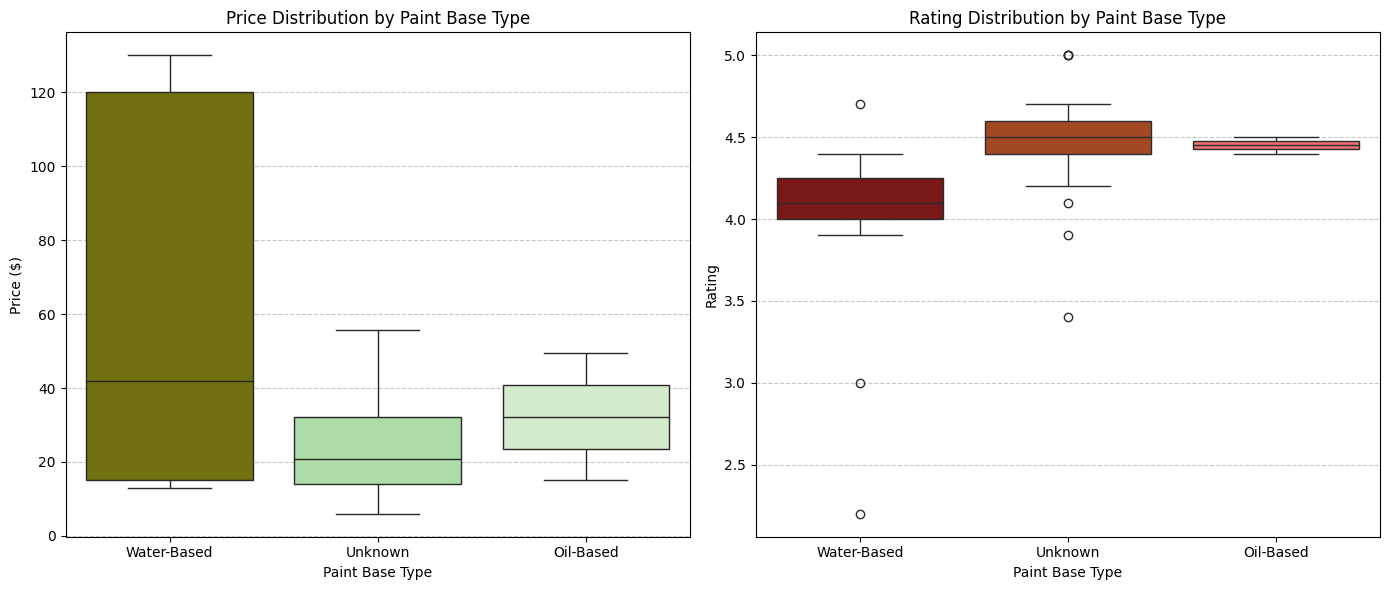

In [12]:

# --- 5. Paint Type Comparison (Base Type) ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot of Price by Base Type
sns.boxplot(x='base_type', y='price_num', data=amazon_df.dropna(subset=['base_type', 'price_num']), ax=axes[0], palette=['#808000', '#A8E4A0', '#D1F0C4'], hue='base_type', legend=False)
axes[0].set_title('Price Distribution by Paint Base Type')
axes[0].set_xlabel('Paint Base Type')
axes[0].set_ylabel('Price ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Box plot of Rating by Base Type
sns.boxplot(x='base_type', y='rating_num', data=amazon_df.dropna(subset=['base_type', 'rating_num']), ax=axes[1], palette=['#880808', '#B7410E', '#FF5C5C'], hue='base_type', legend=False)
axes[1].set_title('Rating Distribution by Paint Base Type')
axes[1].set_xlabel('Paint Base Type')
axes[1].set_ylabel('Rating')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()